In [233]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import colorir as cl
from analyses.parse import parse_cells_multiple

In [18]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path

In [19]:
sims = parse_cells_multiple(sim_paths.values(), 30)

In [20]:
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
celldf = pl.concat(sims)
celldf = celldf.with_columns(displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5)

In [21]:
grouppers = ["gamma", "sim_replica", "time"]
displdf = celldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

gamma,sim_replica,time,cluster_x,cluster_y,mean_displ,med_displ
i32,i32,i32,f32,f32,f32,f32
0,0,0,433.300049,433.299988,614.067871,615.056519
0,0,100000,374.361847,362.397461,530.212097,546.781738
0,0,200000,318.912354,323.1073,474.199799,478.11142
0,0,300000,287.697052,289.229279,430.144165,467.157349
0,0,400000,280.46048,275.529236,425.530945,445.333221
…,…,…,…,…,…,…
20,4,14500000,77.122459,74.833153,116.028175,122.764511
20,4,14600000,82.664749,79.359482,121.106537,124.670845
20,4,14700000,89.211922,73.46209,122.026901,123.379669


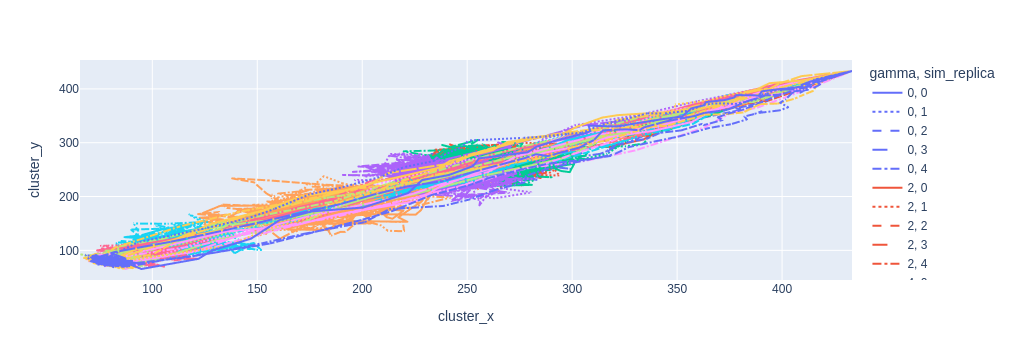

In [22]:
# Cluster trajectories
px.line(
    displdf,
    x="cluster_x",
    y="cluster_y",
    color="gamma",
    line_dash="sim_replica"
)

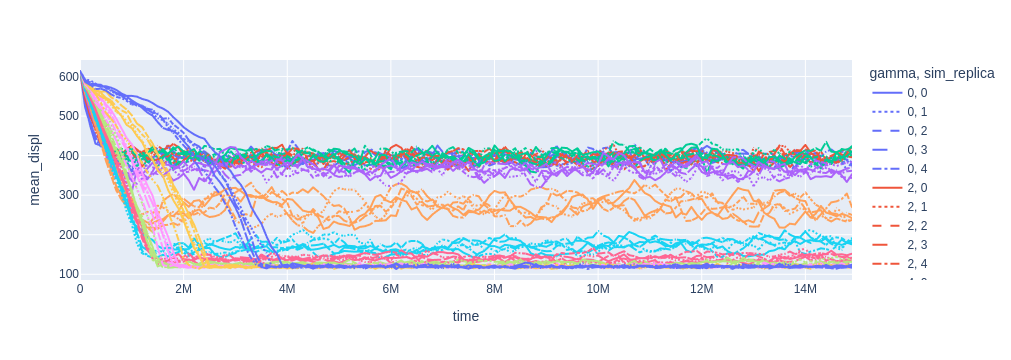

In [23]:
px.line(
    displdf,
    x="time",
    y="mean_displ",
    color="gamma",
    line_dash="sim_replica"
)

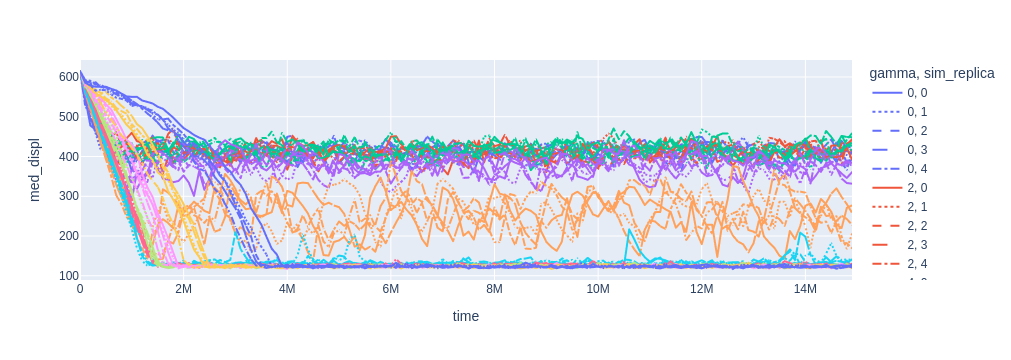

In [159]:
px.line(
    displdf,
    x="time",
    y="med_displ",
    color="gamma",
    line_dash="sim_replica"
)

In [160]:
repldf = displdf.group_by(["gamma", "time"]).agg(
    med_med=pl.col("med_displ").median(),
    med_mean=pl.col("med_displ").mean(),
    med_min=pl.col("med_displ").min(),
    med_max=pl.col("med_displ").max(),
    mean_mean=pl.col("mean_displ").mean(),
    mean_med=pl.col("mean_displ").median(),
    mean_min=pl.col("mean_displ").min(),
    mean_max=pl.col("mean_displ").max(),
).sort(["gamma", "time"])
repldf

gamma,time,med_med,med_mean,med_min,med_max,mean_mean,mean_med,mean_min,mean_max
i32,i32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,615.056519,615.056519,615.056519,615.056519,614.067871,614.067871,614.067871,614.067993
0,100000,536.782532,537.724731,528.370239,546.781738,528.337341,530.212097,521.556396,534.718506
0,200000,498.899963,493.850891,478.11142,500.450867,481.424316,482.607727,474.199799,488.611176
0,300000,467.157349,465.389404,458.508728,473.991516,442.056885,443.143951,430.144165,451.102112
0,400000,445.123291,439.624664,416.558777,447.097595,427.604736,428.804565,422.975983,430.508698
…,…,…,…,…,…,…,…,…,…
20,14500000,122.293686,122.003311,120.38105,123.304123,117.562767,118.326614,115.148811,119.221054
20,14600000,124.670845,122.635887,117.901688,125.459671,119.133034,120.730263,114.031639,122.338379
20,14700000,120.881912,121.953514,119.597107,126.012596,118.925034,117.912323,116.242958,122.15612


/tmp/ipykernel_2229233/3328495102.py:3: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



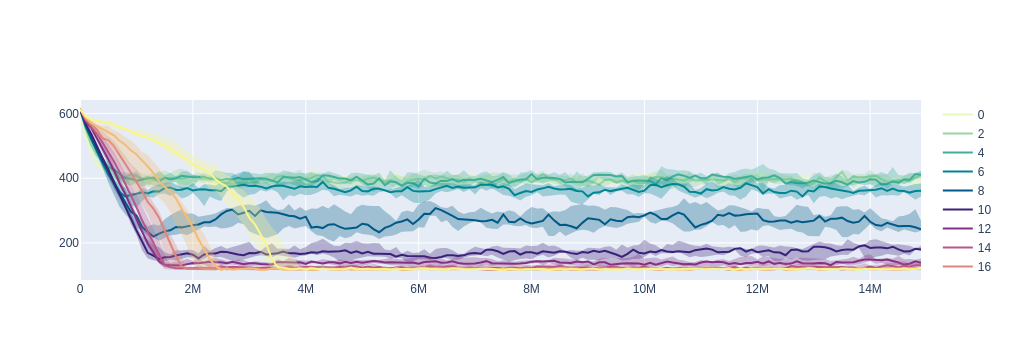

In [292]:
import random as rand

palette = cl.Grad(cl.StackPalette.load("carnival"), domain=[0, 20])
fig = go.Figure()
for gamma, group in repldf.group_by("gamma"):
    gamma = gamma[0]
    fig.add_trace(go.Scatter(
        x=group["time"],
        y=group["mean_med"],
        line_color=palette(gamma),
        name=gamma
    ))
    fig.add_trace(go.Scatter(
        x=pl.concat([group["time"], group["time"][::-1]]),
        y=pl.concat([group["mean_min"], group["mean_max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor=palette(gamma),
        opacity=0.3,
        showlegend=False
    ))
fig

In [293]:
concdf = displdf.filter(pl.col("time") > 10e6).group_by(["gamma"]).agg(
    med=pl.col("mean_displ").median(),
    min=pl.col("mean_displ").min(),
    max=pl.col("mean_displ").max(),
)
concdf

gamma,med,min,max
i32,f32,f32,f32
0,394.49118,360.31073,428.470856
2,396.237885,361.216217,427.734467
4,396.484467,354.667816,444.372894
6,364.045074,322.777588,407.120911
8,269.016846,217.816711,338.347137
…,…,…,…
12,139.383881,124.153564,165.040268
14,123.359787,114.844238,144.442886
16,119.1334,113.931862,129.960297


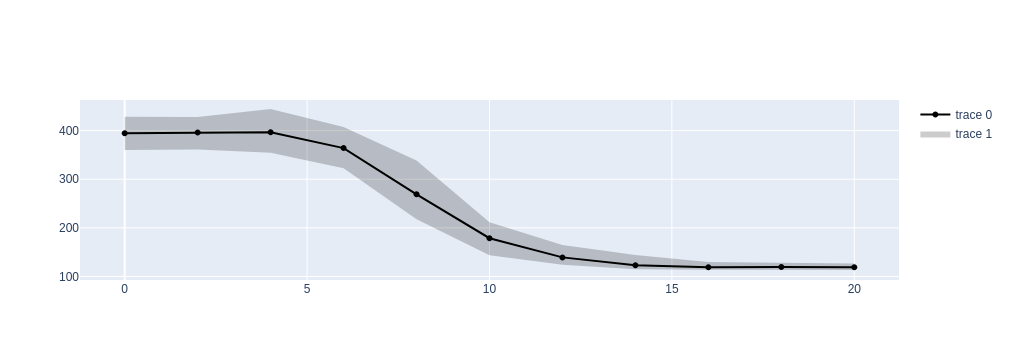

In [294]:
fig = go.Figure([
    go.Scatter(
        x=concdf["gamma"],
        y=concdf["med"],
        line_color="black"
    ),
    go.Scatter(
        x=pl.concat([concdf["gamma"], concdf["gamma"][::-1]]),
        y=pl.concat([concdf["min"], concdf["max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor="rgba(0, 0, 0, 0.2)"
    )
])
fig

In [295]:
cellveldf = celldf.filter(pl.col("time") > 0.5e6).group_by(["gamma", "sim_replica", "index"]).agg(
    msd=(pl.col("displ").sort_by("time").diff() ** 2).mean()
)
cellveldf

gamma,sim_replica,index,msd
i32,i32,u32,f32
6,0,81,8966.804688
12,1,16,2231.966553
4,1,75,10668.353516
20,2,86,1210.161865
10,0,36,4117.100098
…,…,…,…
4,0,54,14437.805664
2,4,51,18712.736328
6,1,49,10968.800781


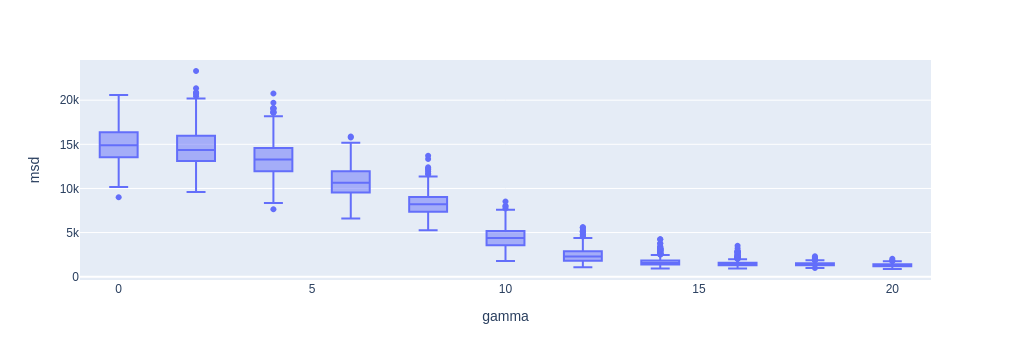

In [296]:
px.box(cellveldf, x="gamma", y="msd").update_layout(width=600)

In [306]:
clusterveldf = displdf.sort("time").filter(pl.col("time") > 0.5e6).group_by(["gamma", "sim_replica"]).agg(
    msd=(
        pl.col("mean_displ")
            .filter(
                pl.col("time") < pl.col("time").filter(pl.col("mean_displ") < 200).sort().first()
            )
            .diff() ** 2
    ).mean()
)
clusterveldf

gamma,sim_replica,msd
i32,i32,f32
16,2,983.247375
0,2,null
20,0,199.468872
20,4,264.719879
16,0,918.595764
…,…,…
12,3,1210.869873
12,0,1271.777466
4,1,null


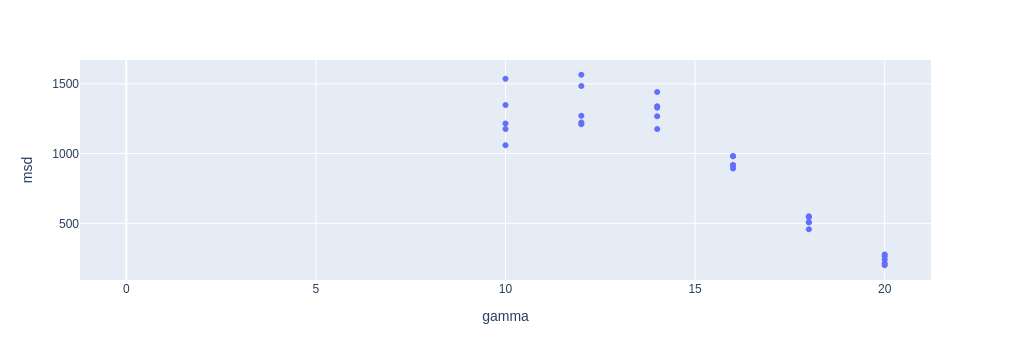

In [307]:
px.scatter(clusterveldf, x="gamma", y="msd").update_layout(width=600)

In [313]:
veldf = cellveldf.join(
    clusterveldf, 
    ["gamma", "sim_replica"],
    suffix="_cluster"
).group_by("gamma").agg(
    mean_msd=pl.col("msd").mean(),
    mean_msd_cluster=pl.col("msd_cluster").mean()
)
veldf

gamma,mean_msd,mean_msd_cluster
i32,f32,f32
4,13335.829102,null
10,4454.661621,1267.607422
14,1711.848267,1310.509521
20,1307.490601,239.202881
6,10765.705078,null
…,…,…
12,2440.031006,1351.094849
16,1489.429565,938.675354
8,8285.477539,null


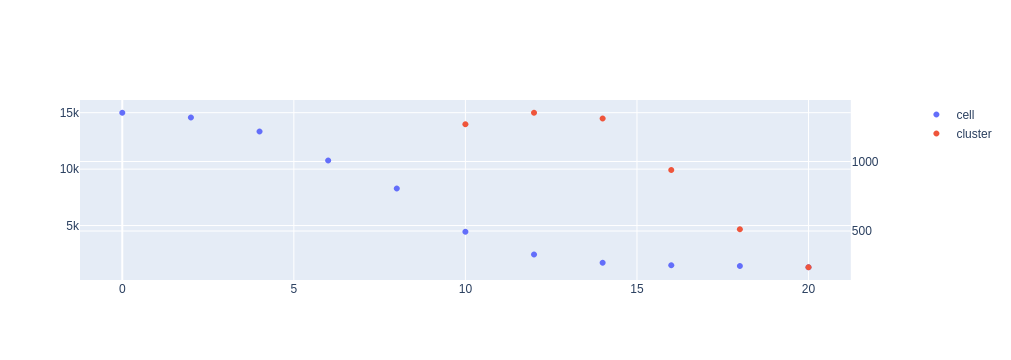

In [314]:
# Non-linear relationship between cell speed and cluster speed
# Or it is linear but strength of CIL depends on gamma? 
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_msd"],
    mode="markers",
    name="cell"
))
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_msd_cluster"],
    mode="markers",
    name="cluster"
), secondary_y=True)